# Agentic Wi-Fi Spatial Attribution — **Computations & Visualisations**

**Notebook 2 of 2.** This notebook imports the `awa` reference-core package and
reproduces the platform's key **computations and figures**. It ships with saved
outputs, so it renders on Zenodo/GitHub without being re-run; re-running it in
Colab regenerates identical results (everything is seeded).

Contents:

1. Setup — make the `awa` package importable (Colab-friendly).
2. A single incident: fused posterior with zones, sensors, MAP and 95% HPD.
3. **Modality decomposition** — RSSI-only vs FTM-only vs fused.
4. **Adversarial-scenario sweep** — HPD area, anomaly, consistency, SOC tier.
5. **Calibration** — empirical HPD coverage vs nominal + localisation-error CDF.
6. **Readiness gating** — claimed vs evidence-supported TRL/CRL/IRL/OR.
7. A validated **Spatial Attribution Record** (SAR).

> ⚠️ Synthetic data only. Accuracy numbers are sanity bounds on a synthetic
> scene, **not** validated field performance.

## 1. Setup — import the `awa` package

In [1]:
import os, sys, subprocess

def _ensure_awa():
    try:
        import awa  # already importable?
        return
    except ImportError:
        pass
    # Look for a local checkout (repo root contains agentic-wifi-attribution/awa)
    for p in ['.', '..', 'agentic-wifi-attribution',
              'bnt/agentic-wifi-attribution',
              '/content/bnt/agentic-wifi-attribution']:
        if os.path.isdir(os.path.join(p, 'awa')):
            sys.path.insert(0, os.path.abspath(p)); return
    # Colab fallback: clone the repository
    if not os.path.isdir('bnt'):
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/omega2417/bnt'], check=False)
    sys.path.insert(0, os.path.abspath('bnt/agentic-wifi-attribution'))

_ensure_awa()
import numpy as np
import matplotlib.pyplot as plt
import awa
from awa.api import build_environment, run_incident
from awa.digital_twin.twin import Scenario
from awa.localization import metrics, fusion
print("awa version:", awa.__version__)

awa version: 0.1.0


## 2. One incident: the fused posterior

A source in the **critical** zone under clean line-of-sight conditions.

MAP: [32.25 13.25]  error: 1.46 m
HPD area: 8.8 m^2  (mass 0.953)
zone posterior: {'Z-public': 0.0, 'Z-controlled': 0.0, 'Z-critical': 1.0, 'unzoned': 0.0}


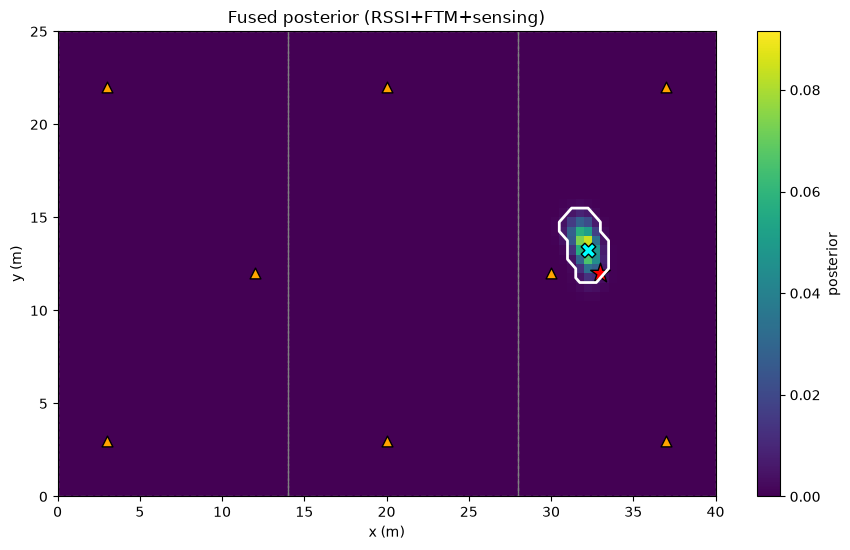

In [2]:
env = build_environment(seed=1)
grid = env.grid
TRUE = (33.0, 12.0)
ctx = run_incident(env, TRUE, "INC-DEMO", Scenario.CLEAN_LOS, seed=777)

mask, achieved, area = metrics.hpd_region(grid, ctx.posterior, 0.95)
mp = np.array(ctx.uncertainty["MAP"])
print("MAP:", np.round(mp, 2), " error: %.2f m" % np.linalg.norm(mp-np.array(TRUE)))
print("HPD area: %.1f m^2  (mass %.3f)" % (area, achieved))
print("zone posterior:", {k: round(v,3) for k,v in ctx.uncertainty["zone_posterior"].items()})

def plot_posterior(ax, p, title):
    img = grid.as_image(p)
    pc = ax.pcolormesh(grid.gx, grid.gy, img, shading="auto", cmap="viridis")
    for z in env.site.zones:
        ax.plot([z.x_min,z.x_max,z.x_max,z.x_min,z.x_min],
                [z.y_min,z.y_min,z.y_max,z.y_max,z.y_min],
                color="grey", ls="--", lw=1)
    sx=[s.x for s in env.site.sensors]; sy=[s.y for s in env.site.sensors]
    ax.scatter(sx, sy, marker="^", c="orange", s=60, edgecolor="k")
    ax.scatter(*TRUE, marker="*", c="red", s=220, edgecolor="k")
    ax.scatter(mp[0], mp[1], marker="X", c="cyan", s=110, edgecolor="k")
    ax.set_title(title); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    return pc

fig, ax = plt.subplots(figsize=(9,5.6))
pc = plot_posterior(ax, ctx.posterior, "Fused posterior (RSSI+FTM+sensing)")
ax.contour(grid.gx, grid.gy, grid.as_image(mask.astype(float)),
           levels=[0.5], colors="white", linewidths=2)
plt.colorbar(pc, ax=ax, label="posterior"); plt.tight_layout(); plt.show()

## 3. Modality decomposition

Each modality on its own, then fused. RSSI is a broad coverage modality; FTM/RTT
sharpens the estimate; the fusion is tighter than either alone.

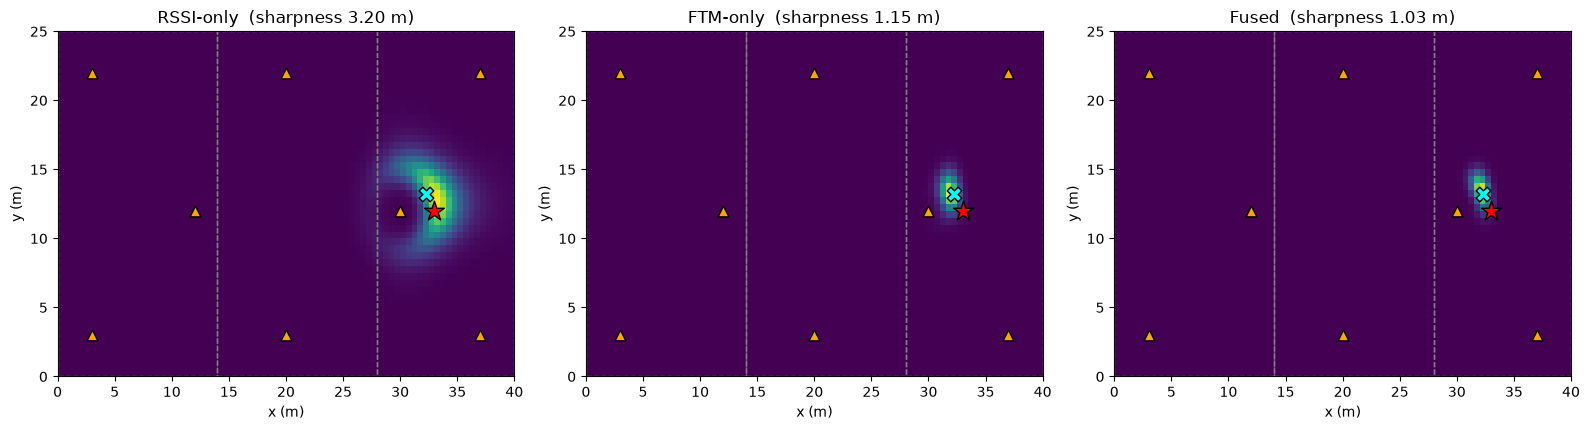

HPD overlap (RSSI vs FTM): 0.938
consistency status        : CONSISTENT


In [3]:
sensors = {s.sensor_id: s for s in env.site.sensors}
rssi_ll = fusion.rssi_log_likelihood(grid, env.radiomap, ctx.sample.rssi, env.cfg.rssi)
ftm_ll  = fusion.ftm_log_likelihood(grid, sensors, ctx.sample.rtt_s, env.cfg.ftm)
p_rssi = fusion.fuse(grid, rssi_ll=rssi_ll).posterior
p_ftm  = fusion.fuse(grid, ftm_ll=ftm_ll).posterior

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, p, t in zip(axes, [p_rssi, p_ftm, ctx.posterior],
                    ["RSSI-only", "FTM-only", "Fused"]):
    plot_posterior(ax, p, f"{t}  (sharpness {metrics.sharpness(grid,p):.2f} m)")
plt.tight_layout(); plt.show()

print("HPD overlap (RSSI vs FTM): %.3f" % metrics.hpd_overlap(grid, p_rssi, p_ftm))
print("consistency status        :", ctx.consistency["status"])

## 4. Adversarial / degradation scenario sweep

Run every scenario for the same true source and compare uncertainty, anomaly,
consistency and the resulting bounded SOC decision.

scenario                   HPD m^2  anomaly   resid consist     SOC tier          
clean_los                     14.5     0.19     2.8 CONSISTENT  ENRICH            
clean_nlos                    25.0     0.20     2.9 UNCERTAIN   ENRICH            
temporal_drift                19.2     0.50     7.4 UNCERTAIN   HUMAN_IN_THE_LOOP 
missing_ftm                   79.8     0.21     3.2 UNCERTAIN   ENRICH            
rogue_ap                      21.0     0.91    13.7 UNCERTAIN   HUMAN_IN_THE_LOOP 
relay                         39.8     0.60     2.8 CONFLICT    HUMAN_IN_THE_LOOP 
selective_jamming             13.2     0.46     6.9 CONSISTENT  HUMAN_IN_THE_LOOP 
rssi_power_manipulation       23.2     0.57     8.6 CONSISTENT  HUMAN_IN_THE_LOOP 


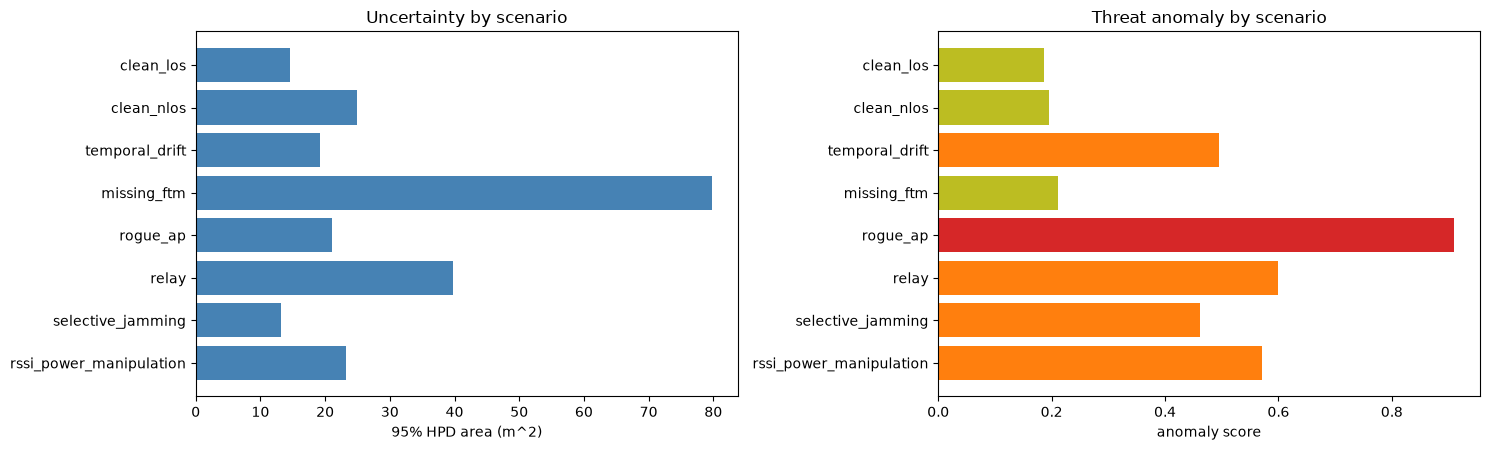

In [4]:
scenarios = [Scenario.CLEAN_LOS, Scenario.CLEAN_NLOS, Scenario.TEMPORAL_DRIFT,
             Scenario.MISSING_FTM, Scenario.ROGUE_AP, Scenario.RELAY,
             Scenario.SELECTIVE_JAMMING, Scenario.RSSI_POWER_MANIPULATION]
rows = []
for sc in scenarios:
    c2 = run_incident(env, TRUE, "SW-"+sc.value, sc, seed=2024)
    rows.append(dict(
        scenario=sc.value,
        hpd_area=c2.uncertainty["HPD_area_m2"],
        anomaly=c2.threat_state["anomaly_score"],
        threat=c2.threat_state["level"],
        consistency=c2.consistency["status"],
        tier=c2.decision["recommended_action"],
        resid=c2.drift_state["twin_residual_db"],
    ))

print("%-24s %9s %8s %7s %-11s %-18s" % ("scenario","HPD m^2","anomaly","resid","consist","SOC tier"))
for r in rows:
    print("%-24s %9.1f %8.2f %7.1f %-11s %-18s" %
          (r["scenario"], r["hpd_area"], r["anomaly"], r["resid"],
           r["consistency"], r["tier"]))

names = [r["scenario"] for r in rows]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.6))
a1.barh(names, [r["hpd_area"] for r in rows], color="steelblue")
a1.set_xlabel("95% HPD area (m^2)"); a1.set_title("Uncertainty by scenario"); a1.invert_yaxis()
colors = {"none":"#2ca02c","low":"#bcbd22","medium":"#ff7f0e","high":"#d62728"}
a2.barh(names, [r["anomaly"] for r in rows],
        color=[colors[r["threat"]] for r in rows])
a2.set_xlabel("anomaly score"); a2.set_title("Threat anomaly by scenario"); a2.invert_yaxis()
plt.tight_layout(); plt.show()

## 5. Calibration & error CDF (Monte-Carlo)

Draw many clean incidents at random true locations and measure:
- **HPD coverage** — how often the true location falls inside the nominal-mass
  HPD region (a well-calibrated system tracks the diagonal), and
- the **localisation-error CDF** (P50/P90/P95).

N=150 incidents
error  P50=0.66 m  P90=1.27 m  P95=1.48 m


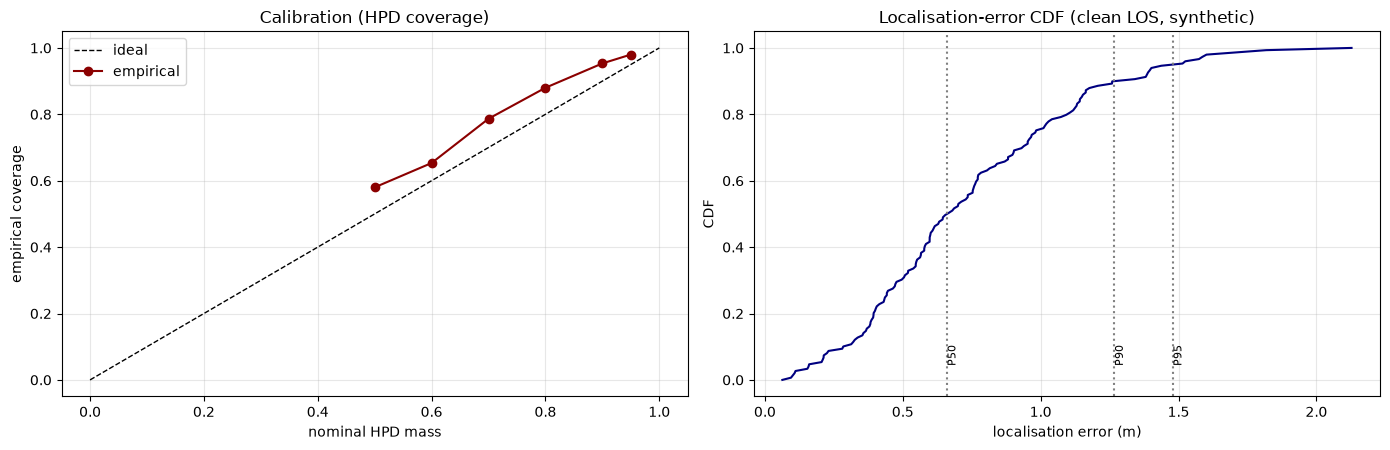

In [5]:
N = 150
rs = np.random.default_rng(7)
nominals = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
covered = {m: 0 for m in nominals}
errors = []
for i in range(N):
    tx = rs.uniform(2, 38); ty = rs.uniform(2, 23)
    ci = run_incident(env, (tx, ty), f"MC{i}", Scenario.CLEAN_LOS, seed=1000+i)
    p = ci.posterior
    idx = grid.nearest_index(tx, ty)
    for m in nominals:
        mask_m, _, _ = metrics.hpd_region(grid, p, m)
        if mask_m[idx]:
            covered[m] += 1
    mp = np.array(ci.uncertainty["MAP"])
    errors.append(float(np.linalg.norm(mp - np.array([tx, ty]))))

emp = [covered[m]/N for m in nominals]
errors = np.array(sorted(errors))
p50, p90, p95 = np.percentile(errors, [50, 90, 95])
print("N=%d incidents" % N)
print("error  P50=%.2f m  P90=%.2f m  P95=%.2f m" % (p50, p90, p95))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.6))
a1.plot([0,1],[0,1], "k--", lw=1, label="ideal")
a1.plot(nominals, emp, "o-", color="darkred", label="empirical")
a1.set_xlabel("nominal HPD mass"); a1.set_ylabel("empirical coverage")
a1.set_title("Calibration (HPD coverage)"); a1.legend(); a1.grid(alpha=.3)
a2.plot(errors, np.linspace(0,1,len(errors)), color="navy")
for q,v in [("P50",p50),("P90",p90),("P95",p95)]:
    a2.axvline(v, ls=":", color="grey"); a2.text(v, 0.05, q, rotation=90, fontsize=8)
a2.set_xlabel("localisation error (m)"); a2.set_ylabel("CDF")
a2.set_title("Localisation-error CDF (clean LOS, synthetic)"); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Readiness gating

The readiness model discounts each dimension by its verified evidence and
applies non-compensatory gate rules. Claimed vs evidence-supported levels:

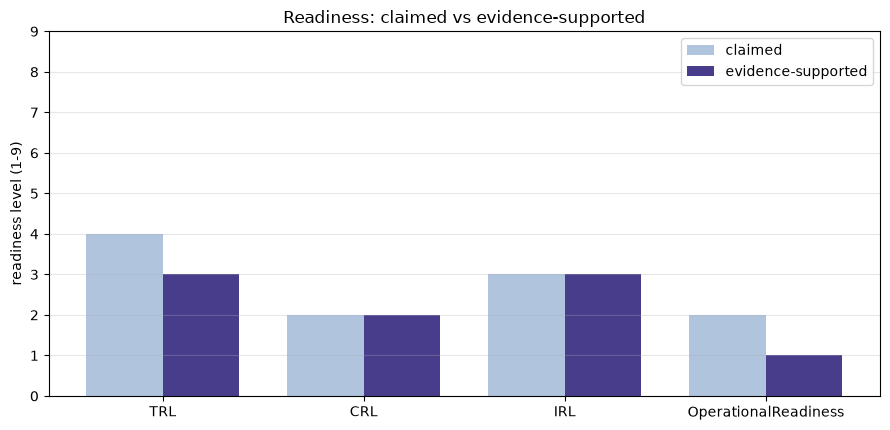

evidence completeness : 0.92
production ready       : False  residual risk: high
gate findings:
blocking gaps:
  - OperationalReadiness: No SOC SOP / incident-response playbook validated


In [6]:
rp = ctx.readiness_profile
dims = ["TRL", "CRL", "IRL", "OperationalReadiness"]
claimed = [rp["claimed"][d] for d in dims]
supported = [rp[d] for d in dims]

fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(dims)); w = 0.38
ax.bar(x-w/2, claimed, w, label="claimed", color="lightsteelblue")
ax.bar(x+w/2, supported, w, label="evidence-supported", color="darkslateblue")
ax.set_xticks(x); ax.set_xticklabels(dims); ax.set_ylim(0, 9)
ax.set_ylabel("readiness level (1-9)")
ax.set_title("Readiness: claimed vs evidence-supported"); ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

print("evidence completeness : %.2f" % rp["evidence_completeness"])
print("production ready       :", rp["production_ready"], " residual risk:", rp["residual_risk"])
print("gate findings:")
for f in rp["gate_findings"]:  print("  -", f)
print("blocking gaps:")
for g in rp["blocking_gaps"]:  print("  -", g)

## 7. The Spatial Attribution Record (validated)

The SAR is the machine-readable evidence output. We validate it against the
shipped JSON Schema and confirm its `provenance_hash`.

In [7]:
import json, jsonschema, hashlib
from awa.evidence.sar import sar_provenance_hash

schema_path = None
for p in ['schemas/sar.schema.json', '../schemas/sar.schema.json',
          'agentic-wifi-attribution/schemas/sar.schema.json',
          'bnt/agentic-wifi-attribution/schemas/sar.schema.json']:
    if os.path.exists(p): schema_path = p; break

rogue = run_incident(env, TRUE, "INC-ROGUE-SAR", Scenario.ROGUE_AP, seed=777)
sar = rogue.sar
if schema_path:
    jsonschema.validate(sar, json.load(open(schema_path)))
    print("SAR validates against schema:", schema_path)
print("provenance_hash intact:", sar["provenance_hash"] == sar_provenance_hash(sar))
print()
print(json.dumps({k: sar[k] for k in
      ["incident_id","site_id","MAP","HPD_mass","threat_state",
       "modality_consistency","recommended_action","decision_tier",
       "human_review_status","provenance_hash"]}, indent=2))

SAR validates against schema: ../schemas/sar.schema.json
provenance_hash intact: True

{
  "incident_id": "INC-ROGUE-SAR",
  "site_id": "SITE-DEMO-001",
  "MAP": [
    31.75,
    13.75
  ],
  "HPD_mass": 0.9504,
  "threat_state": {
    "level": "high",
    "anomaly_score": 0.905,
    "indicators": [
      "high_twin_residual"
    ]
  },
  "modality_consistency": {
    "status": "CONSISTENT",
    "hpd_overlap": 0.7292,
    "map_mahalanobis": 1.289,
    "jensen_shannon": 0.6492
  },
  "recommended_action": "HUMAN_IN_THE_LOOP",
  "decision_tier": 4,
  "human_review_status": "pending",
  "provenance_hash": "14fd48d2eb7d764de9c97b6c12e6df5b1bf050cc9dc24ad2f545e7129ffdb236"
}


## Summary

This notebook reproduced, from the `awa` package: the fused posterior and its
modality decomposition, an adversarial-scenario sweep, a calibration curve and
error CDF over many incidents, the non-compensatory readiness gating, and a
schema-validated, hash-anchored SAR.

Together with the autonomous **Notebook 1**, these artefacts make the reference
core reproducible on Google Colab and archivable on Zenodo.

**Honest caveats.** Results are on synthetic, model-based telemetry; the
absolute error numbers do not transfer to real sites, and subtle relay attacks
with small uniform delays remain only weakly separable here — see
`docs/ARCHITECTURE.md` and the README *Limitations* section.